In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
basic_columns = ['RA', 'DEC', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS', 'PHOTSYS', 'SV1_DESI_TARGET']
photom_columns = ['EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FIBERFLUX_Z']
pz_columns = ['Z_PHOT_MEDIAN']

cat0 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_basic.fits', columns=basic_columns))
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_photom.fits', columns=photom_columns))
pz = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_more_1.fits', columns=pz_columns))
cat = hstack([cat0, cat, pz], join_type='exact')
print(len(cat))

31485458


In [6]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [4]:
maskbits = [1, 8, 9, 11, 12, 13]

mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
print(len(cat))

0.08719844570785662
28739975


In [5]:
# Select LRG_SV_IR
mask = cat['SV1_DESI_TARGET'] & 2**6 > 0
print(np.sum(mask)/len(mask))
cat = cat[mask]
print(len(cat))

0.8601129959229261
24719626


In [30]:
mask = cat['zfibermag']<22.
print(np.sum(mask)/len(mask))
cat = cat[mask]

0.9647291589282135


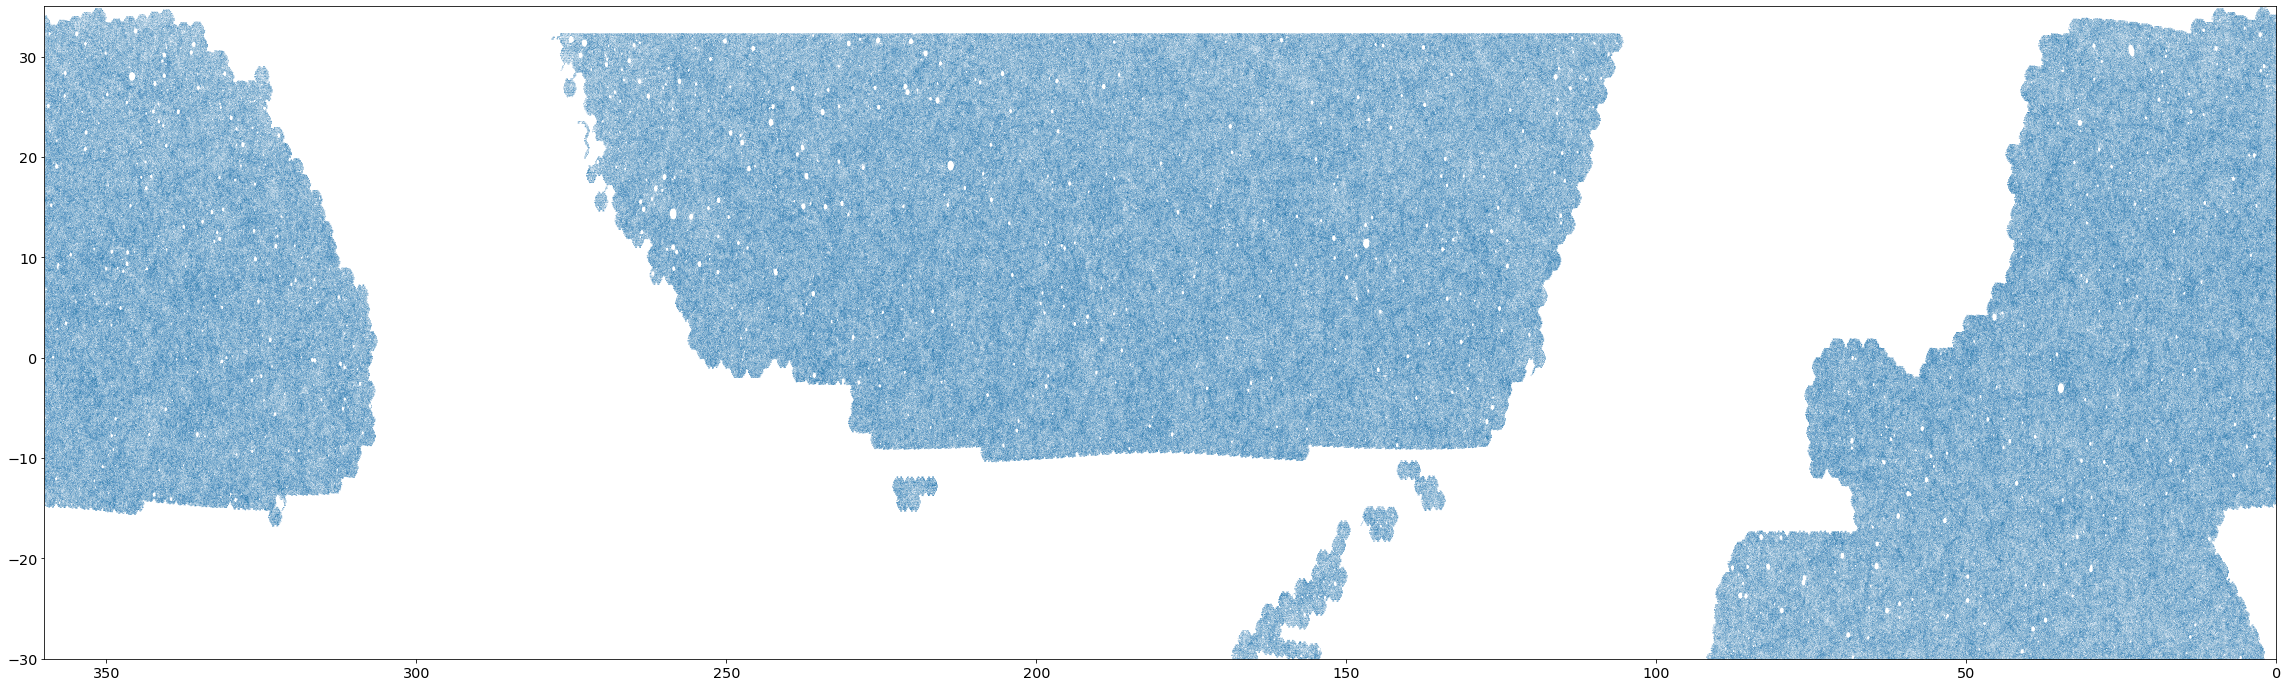

In [31]:
plt.figure(figsize=(40, 12))
plt.plot(cat['RA'], cat['DEC'], '.', ms=0.2, alpha=0.1)
plt.axis([360, 0, -30, 35])
plt.show()

In [54]:
mask_zfib = cat['zfibermag']<21.8
print(np.sum(mask)/len(mask))

0.21273697839091193


---------
# r-W1 bins

In [38]:
rmag, w1mag = cat['rmag'], cat['w1mag']

3.0999985


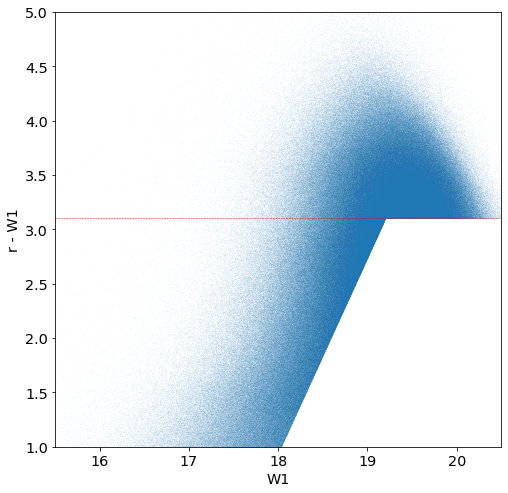

In [39]:
mask = w1mag>19.5
print((rmag - w1mag)[mask].min())

np.random.seed(613)
idx = np.random.choice(len(cat), size=int(2e6), replace=False)

plt.figure(figsize=(8, 8))
plt.plot(w1mag[idx], (rmag - w1mag)[idx], '.', ms=0.1, alpha=0.2)
plt.xlabel('W1')
plt.ylabel('r - W1')
plt.axhline(3.1, lw=0.5, color='r', ls='--')
plt.axis([15.5, 20.5, 1, 5.])
plt.show()

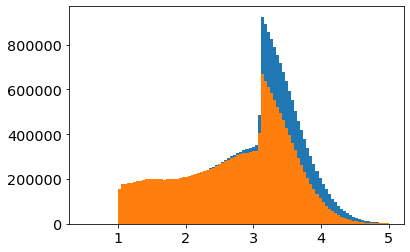

In [49]:
plt.hist(rmag - w1mag, 100, range=(0.5, 5))
plt.hist((rmag - w1mag)[mask_zfib], 100, range=(0.5, 5))
plt.show()

In [51]:
mask = rmag - w1mag > 3.1
print(np.sum(mask)/len(mask))
mask = rmag - w1mag > 3.1
print(np.sum(mask & mask_zfib)/np.sum(mask_zfib))

0.5322174290364741
0.4312790312458353


In [55]:
cat = cat[mask_zfiber]
print(len(cat))

rmag, w1mag = cat['rmag'], cat['w1mag']

19291499


In [56]:
np.percentile(rmag - w1mag, [0.001, 20, 40, 60, 80, 99.9])

array([1.0000515 , 1.90060043, 2.63096237, 3.14017296, 3.44808769,
       4.81527711])

In [72]:
rw1_cuts = [1.86, 2.57, 3.1, 3.42]

for index in range(-1, len(rw1_cuts)):
    if index==-1:
        rw1_min, rw1_max = -np.inf, rw1_cuts[0]
    elif index==len(rw1_cuts)-1:
        rw1_min, rw1_max = rw1_cuts[index], np.inf
    else:
        rw1_min, rw1_max = rw1_cuts[index], rw1_cuts[index+1]
    mask = (cat['rmag']-cat['w1mag']>rw1_min) & (cat['rmag']-cat['w1mag']<rw1_max)
    print('{:.2f}% ({:.1f} per sqdeg)'.format(100*np.sum(mask)/len(mask), np.sum(mask)/len(mask)*600))

19.06% (114.3 per sqdeg)
18.97% (113.8 per sqdeg)
18.84% (113.1 per sqdeg)
21.60% (129.6 per sqdeg)
21.53% (129.2 per sqdeg)


---------
# Photo-z bins

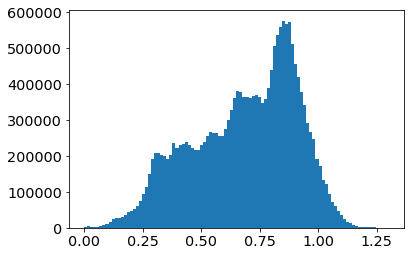

In [73]:
plt.hist(cat['Z_PHOT_MEDIAN'], 100, range=(0., 1.3))
plt.show()

In [74]:
print(cat['Z_PHOT_MEDIAN'].min(), cat['Z_PHOT_MEDIAN'].max())

-99.0 1.4738063


In [75]:
print(np.sum(cat['Z_PHOT_MEDIAN']<0))
print(np.sum(cat['Z_PHOT_MEDIAN']<0)/len(cat))

259
1.3425602644978496e-05


In [76]:
mask = cat['Z_PHOT_MEDIAN']>=0
cat['Z_PHOT_MEDIAN'][mask].min()

0.0042049773

In [77]:
np.percentile(cat['Z_PHOT_MEDIAN'], [0.001, 20, 40, 60, 80, 99.9])

array([-99.        ,   0.46848831,   0.65483564,   0.79170506,
         0.88557422,   1.15940535])

In [79]:
pz_cuts = [0.468, 0.655, 0.792, 0.886]

for index in range(-1, len(pz_cuts)):
    if index==-1:
        pz_min, pz_max = 0, pz_cuts[0]
    elif index==len(pz_cuts)-1:
        pz_min, pz_max = pz_cuts[index], np.inf
    else:
        pz_min, pz_max = pz_cuts[index], pz_cuts[index+1]
    mask = (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    print('{:.2f}% ({:.1f} per sqdeg)'.format(100*np.sum(mask)/len(mask), np.sum(mask)/len(mask)*600))

19.96% (119.7 per sqdeg)
20.06% (120.4 per sqdeg)
20.04% (120.2 per sqdeg)
20.02% (120.1 per sqdeg)
19.92% (119.5 per sqdeg)
